# 600: prepare full df, overview Scenario Group Analysis

This notebook calculates the probability that warming declines after net-zero emissions are achieved,
comparing four groups of scenarios:
1. **Scenarios (NZCO2)**: Scenarios with "NZCO2" in the label
2. **Scenarios (NZGHG)**: Scenarios with "NZKyoto" in the label
3. **Stylised Variants (NZCO2-hold")**
4. **Stylised Variants (NZGHG-hold")**


**Criteria for decline:**
- Delta warming (NZCO2 - 2100) > 0°C

In [1]:
import os
from pathlib import Path

import dotenv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

dotenv.load_dotenv()

True

In [45]:
# Configuration
OUTPUT_FOLDER = Path(os.environ["OUTPUT_FOLDER"])
PLOT_FOLDER = OUTPUT_FOLDER / "plots"
# Guardrails for classifying decline
PEAK_YEAR_THRESHOLD = 2100  # Peak must occur before this year
DELTA_WARMING_THRESHOLD = 0.0  # Minimum decline in °C to count as decline

In [44]:
OUTPUT_FOLDER

PosixPath('/Users/hoegner/GitHub/ar7_netzero_assessment/analysis/output_gaurav/output')

In [3]:
# Input metrics file - uses combined manifest from 401
MANIFEST_ID = "regenerated"
#METRICS_FILE = OUTPUT_FOLDER / f"500_gsat_metrics_{MANIFEST_ID}.csv"
METRICS_FILE = OUTPUT_FOLDER / f"500b_component_metrics_extended_{MANIFEST_ID}.csv"

## Load and Filter Data

In [ ]:
# Load 500b component metrics
all_df = pd.read_csv(OUTPUT_FOLDER / METRICS_FILE, index_col=0)
scenarios = all_df[all_df["scenario_group"]=="Scenarios (NZCO2)"]

EOC_cumulative = pd.read_csv(OUTPUT_FOLDER / "202_cum_em_EOC.csv")

In [302]:
EOC_cumulative["CB_exceedance_50"] = EOC_cumulative["cumulative_co2"]-247
EOC_cumulative["CB_exceedance_33"] = EOC_cumulative["cumulative_co2"]-480
EOC_cumulative["CB_exceedance_67"] = EOC_cumulative["cumulative_co2"]-60

In [303]:
EOC_cumulative

,model,scenario,year_netzero_co2,year_netzero_kyoto_ar6gwp100,achieve_netzero_co2,achieve_netzero_ghg,cumulative_co2,cumulative_netnegative_co2,CB_exceedance,CB_exceedance_50,CB_exceedance_33,CB_exceedance_67
0,AIM/CGE 2.0,SSP1-19,2058.0,2073.0,True,True,532.70,-135.79,282.70,285.70,52.70,472.70
1,AIM/CGE 2.0,SSP2-19,2051.0,2060.0,True,True,452.84,-351.99,202.84,205.84,-27.16,392.84
2,AIM/CGE 2.0,SSP2-26,2072.0,NaN,True,False,803.23,-90.65,553.23,556.23,323.23,743.23
3,AIM/CGE 2.0,SSP3-34,2086.0,NaN,True,False,1268.02,-43.97,1018.02,1021.02,788.02,1208.02
4,AIM/CGE 2.0,SSP4-26,2080.0,NaN,True,False,932.14,-42.94,682.14,685.14,452.14,872.14
...,...,...,...,...,...,...,...,...,...,...,...,...
738,WITCH-GLOBIOM 4.4,CD-LINKS-INDC2030i_1600,2089.0,NaN,True,False,1242.91,-25.67,992.91,995.91,762.91,1182.91
739,WITCH-GLOBIOM 4.4,CD-LINKS-NDC2030i_1000,2068.0,2080.0,True,True,812.25,-199.63,562.25,565.25,332.25,752.25
740,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,2079.0,2093.0,True,True,840.54,-87.41,590.54,593.54,360.54,780.54
741,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1600,2098.0,NaN,True,False,1307.02,-1.73,1057.02,1060.02,827.02,1247.02


In [304]:
scenarios["prob_below_1p5"] = (
    (scenarios["GSAT|ANTHROPOGENIC|2100"] < 1.5)
    .groupby(scenarios["scenario"])
    .transform("mean")
)

/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_7307/4189144097.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scenarios["prob_below_1p5"] = (


In [305]:
scenarios

,model,scenario,run_id,peak_year,year_netzero_co2,GSAT|ALL|peak,GSAT|ALL|netzero_co2,GSAT|ALL|2100,GSAT|NonCO2_GHG|peak_gsat,GSAT|NonCO2_GHG|2100,...,GSAT|CO2_Negative|peak_gsat,GSAT|CO2_Negative|2100,GSAT|CO2_Negative|delta_peak_gsat,GSAT|CO2_Negative|netzero_co2,GSAT|CO2_Negative|delta_netzero_co2,scenario_group,GSAT|ALL|delta_netzero_co2,GSAT|ALL|delta_peak_gsat,is_decline,prob_below_1p5
0,AIM/CGE 2.0,SSP1-19,0,2049,2058,1.612907,1.578769,1.411091,0.092336,-0.093244,...,0.000000,-0.065621,-0.065621,0.0,-0.065621,Scenarios (NZCO2),-0.167678,-0.201816,True,0.621667
1,AIM/CGE 2.0,SSP1-19,1,2093,2058,2.592601,2.542383,2.577173,0.438947,0.419883,...,-0.071348,-0.096158,-0.024810,0.0,-0.096158,Scenarios (NZCO2),0.034790,-0.015427,False,0.621667
2,AIM/CGE 2.0,SSP1-19,2,2049,2058,1.798363,1.756857,1.577004,0.099817,-0.076595,...,0.000000,-0.069052,-0.069052,0.0,-0.069052,Scenarios (NZCO2),-0.179853,-0.221359,True,0.621667
3,AIM/CGE 2.0,SSP1-19,3,2038,2058,1.379944,1.300197,1.074082,0.098739,-0.197705,...,0.000000,-0.052731,-0.052731,0.0,-0.052731,Scenarios (NZCO2),-0.226115,-0.305862,True,0.621667
4,AIM/CGE 2.0,SSP1-19,4,2048,2058,1.645092,1.590230,1.396311,0.107123,-0.111821,...,0.000000,-0.062936,-0.062936,0.0,-0.062936,Scenarios (NZCO2),-0.193919,-0.248781,True,0.621667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1017595,WITCH 5.0,ENGAGE-NPi2020-900f,595,2081,2083,1.751988,1.749015,1.677935,-0.085290,-0.105679,...,0.000000,-0.031792,-0.031792,0.0,-0.031792,Scenarios (NZCO2),-0.071080,-0.074053,True,0.269722
1017596,WITCH 5.0,ENGAGE-NPi2020-900f,596,2100,2083,3.273823,3.175079,3.273823,0.588661,0.588661,...,-0.037479,-0.037479,0.000000,0.0,-0.037479,Scenarios (NZCO2),0.098744,0.000000,False,0.269722
1017597,WITCH 5.0,ENGAGE-NPi2020-900f,597,2100,2083,2.481015,2.418546,2.481015,0.154784,0.154784,...,-0.023841,-0.023841,0.000000,0.0,-0.023841,Scenarios (NZCO2),0.062469,0.000000,False,0.269722
1017598,WITCH 5.0,ENGAGE-NPi2020-900f,598,2082,2083,1.722763,1.720689,1.660469,-0.072006,-0.089002,...,0.000000,-0.028103,-0.028103,0.0,-0.028103,Scenarios (NZCO2),-0.060221,-0.062295,True,0.269722


In [306]:
combined = scenarios.merge(
    EOC_cumulative[['model', 'scenario', 'cumulative_co2', 'cumulative_netnegative_co2', 'CB_exceedance_50', 'CB_exceedance_33', 'CB_exceedance_67']],
    on=['model', 'scenario'],
    how='left'
)

In [307]:
warming_column = "GSAT|ANTHROPOGENIC|2100"

stats = combined.groupby(["model", "scenario", "cumulative_co2", "cumulative_netnegative_co2", "CB_exceedance_50", "CB_exceedance_33", "CB_exceedance_67", "prob_below_1p5"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    median=pd.NamedAgg(column=warming_column, aggfunc="median"),
    p5=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 5)),
    p10=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 10)),
    p17=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 17)),
    p34=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 34)),
    p67=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 67)),
    p83=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 83)),
    p90=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 90)),
    p95=pd.NamedAgg(column=warming_column, aggfunc=lambda x: np.percentile(x, 95)),
).reset_index()
stats

,model,scenario,cumulative_co2,cumulative_netnegative_co2,CB_exceedance_50,CB_exceedance_33,CB_exceedance_67,prob_below_1p5,n_ensemble,median,p5,p10,p17,p34,p67,p83,p90,p95
0,AIM/CGE 2.0,SSP1-19,532.70,-135.79,285.70,52.70,472.70,0.621667,600,1.251860,0.843362,0.910764,0.986785,1.116699,1.382771,1.614239,1.817129,1.974139
1,AIM/CGE 2.0,SSP2-19,452.84,-351.99,205.84,-27.16,392.84,0.736667,600,1.133150,0.797189,0.866876,0.928215,1.020461,1.255844,1.446392,1.616036,1.748272
2,AIM/CGE 2.0,SSP2-26,803.23,-90.65,556.23,323.23,743.23,0.274333,600,1.628297,1.152759,1.233540,1.325990,1.478453,1.788296,2.037752,2.268622,2.455746
3,AIM/CGE 2.0,SSP3-34,1268.02,-43.97,1021.02,788.02,1208.02,0.050833,600,2.067824,1.547939,1.655423,1.718894,1.899363,2.260637,2.518905,2.772830,2.989553
4,AIM/CGE 2.0,SSP4-26,932.14,-42.94,685.14,452.14,872.14,0.280556,600,1.569182,1.151775,1.234973,1.305752,1.440717,1.711192,1.944064,2.165492,2.284379
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
680,WITCH-GLOBIOM 3.1,SSP4-19,523.22,-223.28,276.22,43.22,463.22,0.781667,600,1.257043,0.871620,0.950451,1.019028,1.125338,1.385497,1.582559,1.735458,1.915091
681,WITCH-GLOBIOM 4.4,CD-LINKS-INDC2030i_1600,1242.91,-25.67,995.91,762.91,1182.91,0.235000,600,1.681492,1.129818,1.234610,1.329340,1.509874,1.837924,2.116307,2.350273,2.605165
682,WITCH-GLOBIOM 4.4,CD-LINKS-NDC2030i_1000,812.25,-199.63,565.25,332.25,752.25,0.404667,600,1.358968,0.906607,1.001401,1.072492,1.208789,1.485582,1.708823,1.907838,2.110293
683,WITCH-GLOBIOM 4.4,CD-LINKS-NPi2020_1000,840.54,-87.41,593.54,360.54,780.54,0.412083,600,1.472286,0.994230,1.085934,1.168912,1.312129,1.606624,1.835788,2.046174,2.251948


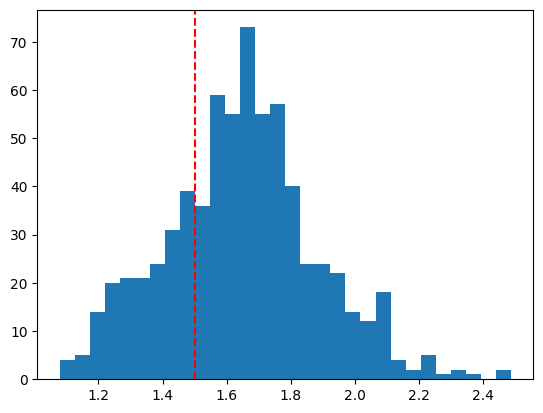

In [258]:
plt.hist(stats["median"], bins=30)
plt.axvline(x=1.5, color="red", linestyle="--");

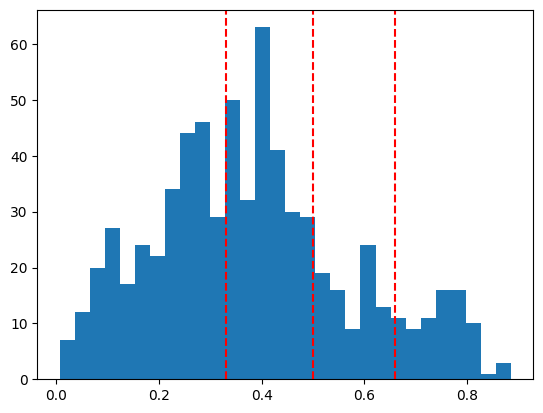

In [259]:
plt.hist(stats["prob_below_1p5"], bins=30)
plt.axvline(x=.33, color="red", linestyle="--")
plt.axvline(x=.50, color="red", linestyle="--")
plt.axvline(x=.66, color="red", linestyle="--");

## Plot effective TCRE in 2100

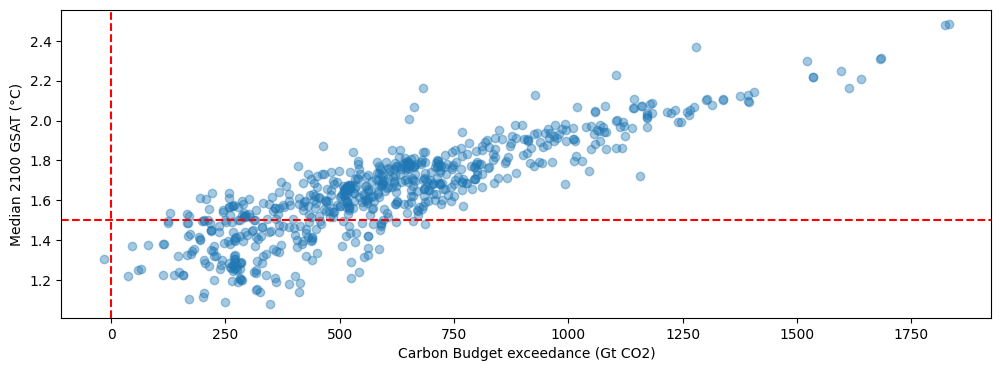

In [260]:
plt.figure(figsize=(12,4))
plt.scatter(stats["CB_exceedance"], stats["median"], alpha=.4)
plt.xlabel("Carbon Budget exceedance (Gt CO2)")
plt.ylabel("Median 2100 GSAT (°C)")
plt.axvline(x=0, color="red", linestyle="--")
plt.axhline(y=1.5, color="red", linestyle="--");

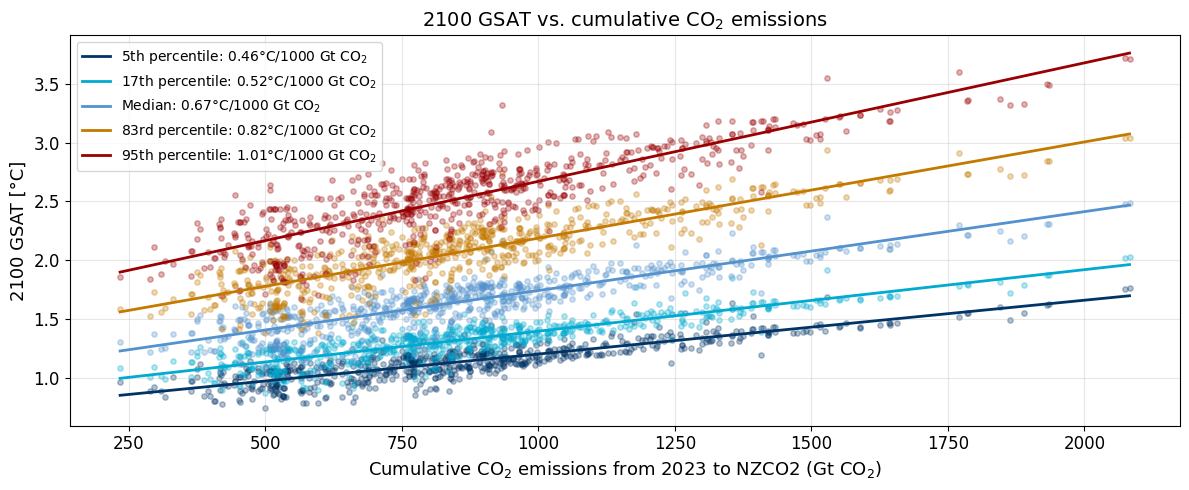

In [263]:
fig, ax = plt.subplots(figsize=(12, 5))

plot_data = stats

# Filter for valid data
x_all = plot_data["cumulative_co2"].values
x_fit = np.linspace(plot_data["cumulative_co2"].min(), plot_data["cumulative_co2"].max(), 100)

percentile_colors = {
    "p5":     "#003466",
    "p17":     "#00aad0",
    "median":  "#5492cd",
    "p83":     "#c47900",
    "p95":     "#990002",
}
percentile_labels = {
    "p5":     "5th percentile",
    "p17":     "17th percentile",
    "median":  "Median",
    "p83":     "83rd percentile",
    "p95":     "95th percentile",
}

for col in ["p5", "p17", "median", "p83", "p95"]:
    y = plot_data[col].values
    hex_color = percentile_colors[col]
    label = percentile_labels[col]

    ax.scatter(x_all, y, facecolors=hex_color, edgecolors=hex_color, alpha=0.3, s=15)

    valid = ~np.isnan(y)
    if valid.sum() > 1:
        slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
        ax.plot(x_fit, slope * x_fit + intercept,
                color=hex_color, linewidth=2,
                label=f"{label}: {slope*1000:.2f}°C/1000 Gt CO$_2$")

ax.set_xlabel("Cumulative CO$_2$ emissions from 2023 to NZCO2 (Gt CO$_2$)", fontsize=13)
ax.set_ylabel("2100 GSAT [°C]", fontsize=13)
ax.set_title("2100 GSAT vs. cumulative CO$_2$ emissions", fontsize=14)
ax.legend(fontsize=10, loc="upper left")
ax.grid(alpha=0.3)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.savefig(PLOT_FOLDER / "GSAT_2100_vs_cumCO2.png", dpi=300, bbox_inches="tight")
plt.show()

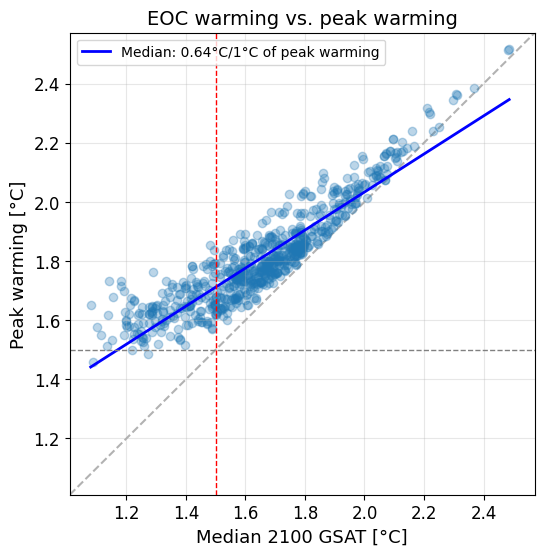

In [264]:
stats_check = combined.groupby(["model", "scenario", "cumulative_co2"]).agg(
    n_ensemble=pd.NamedAgg(column="run_id", aggfunc="count"),
    median_peak=pd.NamedAgg(column="GSAT|ANTHROPOGENIC|peak", aggfunc="median"),
    median_2100=pd.NamedAgg(column="GSAT|ANTHROPOGENIC|2100", aggfunc="median"),
).reset_index()

fig, ax = plt.subplots(figsize=(6, 6))

x_all = stats_check["median_2100"].values
x_fit = np.linspace(stats_check["median_2100"].min(), stats_check["median_2100"].max(), 100)
y = stats_check["median_peak"]

ax.scatter(x_all, y, alpha=.3)

valid = ~np.isnan(y)
if valid.sum() > 1:
    slope, intercept = np.polyfit(x_all[valid], y[valid], 1)
    ax.plot(x_fit, slope * x_fit + intercept,
            color="blue", linewidth=2,
            label=f"Median: {slope:.2f}°C/1°C of peak warming")

ax.set_xlabel("Median 2100 GSAT [°C]", fontsize=13)
ax.set_ylabel("Peak warming [°C]", fontsize=13)
ax.set_title("EOC warming vs. peak warming", fontsize=14)
ax.legend(fontsize=10, loc="upper left")

ax.axhline(1.5, color='gray', ls='--', lw=1)
ax.axvline(1.5, color='red', ls='--', lw=1)
lims = [
    min(ax.get_xlim()[0], ax.get_ylim()[0]),
    max(ax.get_xlim()[1], ax.get_ylim()[1]),
]
ax.plot(lims, lims, 'k--', alpha=0.3, zorder=0, label='1:1')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.grid(alpha=0.3)
ax.tick_params(axis="both", labelsize=12)

In [265]:
stats["CB_exceedance"].max()

np.float64(1832.52)

## Table 1 Probability of GSAT decline from NZCO2 year

In [282]:
# Row bins: <100, <200, ..., <1000, >1000
row_edges = list(range(0, 800, 50)) + [np.inf]  # [0, 50, 100, ..., 450, inf]

row_labels = []
for i in range(1, len(row_edges) - 1):
    lower, upper = row_edges[i - 1], row_edges[i]
    if lower == 0:
        row_labels.append(f"< {upper} Gt CO$_2$")
    else:
        row_labels.append(f"{lower} to {upper} Gt CO$_2$")

row_labels.append(f"> {row_edges[-2]} Gt CO$_2$")  # final open-ended bin


cb_bins = pd.cut(
    stats["CB_exceedance"],
    bins=[-np.inf] + row_edges[1:],
    labels=row_labels,
)

# Column thresholds: cumulative, not partitioned
col_defs = {
    "> 67%": stats["prob_below_1p5"] > 0.67,
    "> 50%": stats["prob_below_1p5"] > 0.50,
    "> 33%": stats["prob_below_1p5"] > 0.33,
}

table = pd.DataFrame(
    {col_name: cb_bins[mask].value_counts().reindex(row_labels, fill_value=0)
     for col_name, mask in col_defs.items()}
)

table = table[["> 33%", "> 50%", "> 67%"]]

table.index.name = "Exceedance of 2023 RCB"
table

,> 33%,> 50%,> 67%
Exceedance of 2023 RCB,,,
< 50 Gt CO$_2$,3,3,2
50 to 100 Gt CO$_2$,3,3,3
100 to 150 Gt CO$_2$,9,7,4
150 to 200 Gt CO$_2$,18,15,4
200 to 250 Gt CO$_2$,30,27,12
250 to 300 Gt CO$_2$,58,45,24
300 to 350 Gt CO$_2$,31,23,11
350 to 400 Gt CO$_2$,26,12,5
400 to 450 Gt CO$_2$,38,13,4


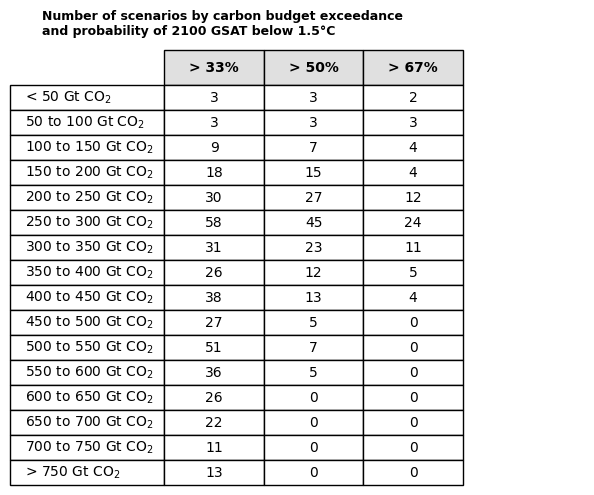

In [312]:
table_data = table  # DataFrame with columns ["> 33%", "> 50%", "> 67%"]
n_cols = len(table_data.columns)
n_rows = len(table_data)

fig, ax = plt.subplots(figsize=(7, n_rows * 0.25 + 0.6))
ax.axis("off")

mpl_table = ax.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    rowLabels=table_data.index,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(10)
mpl_table.scale(0.55, 1.5)

header_height = 0.1
for col_idx in range(n_cols):
    mpl_table[0, col_idx].set_height(header_height)
    mpl_table[0, col_idx].get_text().set_fontweight("bold")
    mpl_table[0, col_idx].set_facecolor("#e0e0e0")


# overall title
ax.set_title(
    "Number of scenarios by carbon budget exceedance\n"
    "and probability of 2100 GSAT below 1.5°C",
    fontsize=9, fontweight="bold", pad=40, loc="left"
)

plt.show()
fig.savefig(Path(PLOT_FOLDER / "CB_exceedance_1p5.png"), bbox_inches="tight", dpi=300)
#plt.close(fig)

In [322]:
# Row bins: <100, <200, ..., <1000, >1000
row_edges = list(range(0, 650, 50)) + [np.inf]  # [0, 50, 100, ..., 450, inf]

row_labels = []
for i in range(1, len(row_edges) - 1):
    lower, upper = row_edges[i - 1], row_edges[i]
    if lower == 0:
        row_labels.append(f"< {upper} Gt CO$_2$")
    else:
        row_labels.append(f"{lower} to {upper} Gt CO$_2$")

row_labels.append(f"> {row_edges[-2]} Gt CO$_2$")  # final open-ended bin


col_defs = {
    "> 33% (RCB 480 Gt CO$_2$)": ("prob_below_1p5", 0.33, "CB_exceedance_33"),
    "> 50% (RCB 247 Gt CO$_2$)": ("prob_below_1p5", 0.50, "CB_exceedance_50"),
    "> 67% (RCB 60 Gt CO$_2$)":  ("prob_below_1p5", 0.67, "CB_exceedance_67"),
}

median_table = pd.DataFrame(index=row_labels, columns=list(col_defs.keys()), dtype=float)
p17_table = pd.DataFrame(index=row_labels, columns=list(col_defs.keys()), dtype=float)
p83_table = pd.DataFrame(index=row_labels, columns=list(col_defs.keys()), dtype=float)
count_table = pd.DataFrame(index=row_labels, columns=list(col_defs.keys()), dtype=int)

for col_name, (prob_col, threshold, cb_col) in col_defs.items():
    mask = stats[prob_col] > threshold
    subset = stats.loc[mask]

    # bin this column's own CB_exceedance variant, using the same row_edges/row_labels
    col_bins = pd.cut(
        subset[cb_col],
        bins=[-np.inf] + row_edges[1:],
        labels=row_labels,
    )

    grouped = subset.groupby(col_bins)["cumulative_netnegative_co2"]

    median_table[col_name] = grouped.median().reindex(row_labels)
    p17_table[col_name] = grouped.quantile(0.17).reindex(row_labels)
    p83_table[col_name] = grouped.quantile(0.83).reindex(row_labels)
    count_table[col_name] = grouped.count().reindex(row_labels, fill_value=0)

# build display strings: "median (p17 to p83) GtCO2 [n=]"
display_table = pd.DataFrame(index=row_labels, columns=list(col_defs.keys()), dtype=object)
for col_name in col_defs:
    for row_label in row_labels:
        n = count_table.loc[row_label, col_name]
        if n < 10:
            display_table.loc[row_label, col_name] = "n<10"
        else:
            med = median_table.loc[row_label, col_name]
            p17 = p17_table.loc[row_label, col_name]
            p83 = p83_table.loc[row_label, col_name]
            display_table.loc[row_label, col_name] = f"{med:.0f} ({p17:.0f} to {p83:.0f}) GtCO$_2$  [n={n}]"

display_table

/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_7307/2748495922.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = subset.groupby(col_bins)["cumulative_netnegative_co2"]
/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_7307/2748495922.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = subset.groupby(col_bins)["cumulative_netnegative_co2"]
/var/folders/y4/5qztk4vn4fq27tgyj0wzy83m0000gn/T/ipykernel_7307/2748495922.py:37: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain 

,> 33% (RCB 480 Gt CO$_2$),> 50% (RCB 247 Gt CO$_2$),> 67% (RCB 60 Gt CO$_2$)
< 50 Gt CO$_2$,-212 (-408 to -3) GtCO$_2$ [n=100],n<10,n<10
50 to 100 Gt CO$_2$,-145 (-338 to -56) GtCO$_2$ [n=41],n<10,n<10
100 to 150 Gt CO$_2$,-216 (-452 to -25) GtCO$_2$ [n=31],n<10,n<10
150 to 200 Gt CO$_2$,-270 (-557 to -26) GtCO$_2$ [n=26],-224 (-401 to -75) GtCO$_2$ [n=15],n<10
200 to 250 Gt CO$_2$,-231 (-288 to -117) GtCO$_2$ [n=34],-192 (-409 to -23) GtCO$_2$ [n=27],n<10
250 to 300 Gt CO$_2$,-124 (-249 to -34) GtCO$_2$ [n=49],-240 (-386 to -107) GtCO$_2$ [n=46],n<10
300 to 350 Gt CO$_2$,-263 (-411 to -98) GtCO$_2$ [n=34],-329 (-528 to -146) GtCO$_2$ [n=22],n<10
350 to 400 Gt CO$_2$,-138 (-271 to -63) GtCO$_2$ [n=33],-286 (-589 to -152) GtCO$_2$ [n=12],n<10
400 to 450 Gt CO$_2$,-189 (-297 to -74) GtCO$_2$ [n=21],-413 (-670 to -76) GtCO$_2$ [n=11],-309 (-372 to -202) GtCO$_2$ [n=11]
450 to 500 Gt CO$_2$,-218 (-335 to -98) GtCO$_2$ [n=17],n<10,-251 (-503 to -87) GtCO$_2$ [n=21]


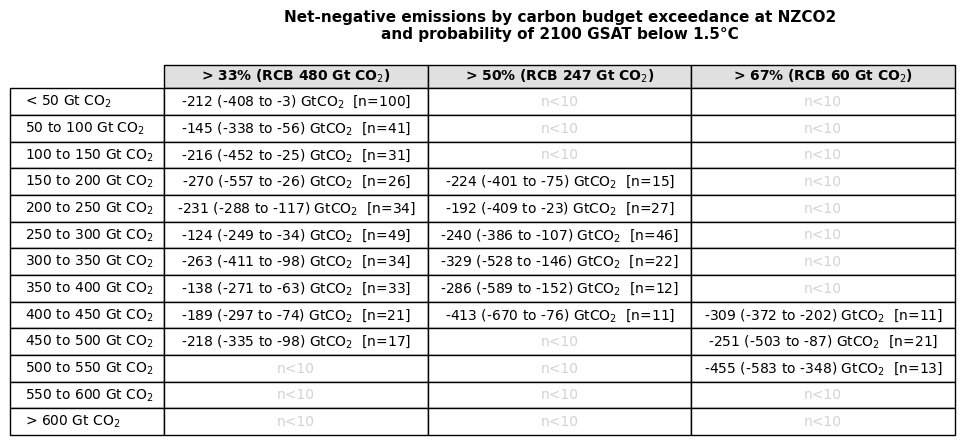

In [323]:
table_data = display_table  # DataFrame with columns ["> 33%", "> 50%", "> 67%"]
n_cols = len(table_data.columns)
n_rows = len(table_data)

fig, ax = plt.subplots(figsize=(6, n_rows * 0.25 + 0.6))
ax.axis("off")

mpl_table = ax.table(
    cellText=display_table.values,
    colLabels=display_table.columns,
    rowLabels=display_table.index,
    loc="center",
    cellLoc="center",
    colLoc="center",
)
mpl_table.auto_set_font_size(False)
mpl_table.set_fontsize(10)
mpl_table.scale(1.7, 1.6)

header_height = 0.08
for col_idx in range(n_cols):
    mpl_table[0, col_idx].set_height(header_height)
    mpl_table[0, col_idx].get_text().set_fontweight("bold")
    mpl_table[0, col_idx].set_facecolor("#e0e0e0")

# grey out "n<10" cells
for (row_idx, col_idx), cell in mpl_table.get_celld().items():
    if row_idx == 0:  # skip header row
        continue
    text = cell.get_text().get_text()
    if text == "n<10":
        cell.get_text().set_color("lightgrey")

# overall title
ax.set_title(
    "Net-negative emissions by carbon budget exceedance at NZCO2\n"
    "and probability of 2100 GSAT below 1.5°C",
    fontsize=11, fontweight="bold", pad=45, loc="center"
)

plt.show()
fig.savefig(Path(PLOT_FOLDER / "CB_exceedance_1p5_negative.png"), bbox_inches="tight", dpi=300)
#plt.close(fig)